# MNIST Loading and Synthetic Image Generation

This notebook performs the following tasks:
1. Load the MNIST dataset
2. Visualize sample images
3. Generate synthetic images using augmentation
4. Save synthetic images in a structured folder

## Import Libraries

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import array_to_img, img_to_array, save_img
from tensorflow.keras.preprocessing.image import load_img, img_to_array

## Load MNIST Dataset

In [18]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = np.expand_dims(x_train, -1)  # (num_samples,28,28,1)
x_test = np.expand_dims(x_test, -1)

print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

Training samples: 60000
Test samples: 10000
Image shape: (28, 28, 1)


## Visualize Sample MNIST Images

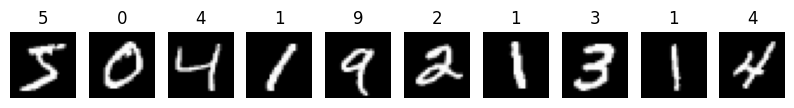

In [19]:
plt.figure(figsize=(10,3))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.show()


## Synthetic MNIST Canvas Generator
### Generate realistic synthetic images by placing multiple MNIST digits on a single large canvas.


In [20]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# Synthetic images folder
synthetic_dir = "../data/synthetic_mnist_canvas"
os.makedirs(synthetic_dir, exist_ok=True)

# Canvas parameters
canvas_size = 256       # canvas size: 256x256
digits_per_canvas = 20  # number of digits per canvas
num_synthetic_images = 1000  # number of synthetic images to generate


def place_digit(canvas, digit_img, x, y):
    """Place a digit on canvas using maximum to avoid overwriting bright pixels."""
    h, w = digit_img.shape
    canvas[y:y+h, x:x+w] = np.maximum(canvas[y:y+h, x:x+w], digit_img)
    return canvas


# Generate synthetic canvases
for i in range(num_synthetic_images):
    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    
    for _ in range(digits_per_canvas):
        # Select random MNIST digit
        idx = np.random.randint(0, len(x_train))
        digit = x_train[idx]

        # Apply augmentation
        digit_aug = datagen.random_transform(digit.reshape(28,28,1)).reshape(28,28)
        digit_aug = (digit_aug * 255).astype(np.uint8)

        # Random position
        x_pos = np.random.randint(0, canvas_size - 28)
        y_pos = np.random.randint(0, canvas_size - 28)

        # Place digit
        canvas = place_digit(canvas, digit_aug, x_pos, y_pos)

    # Save canvas
    save_path = os.path.join(synthetic_dir, f"synthetic_canvas_{i}.png")
    save_img(save_path, canvas.reshape(canvas_size, canvas_size, 1))




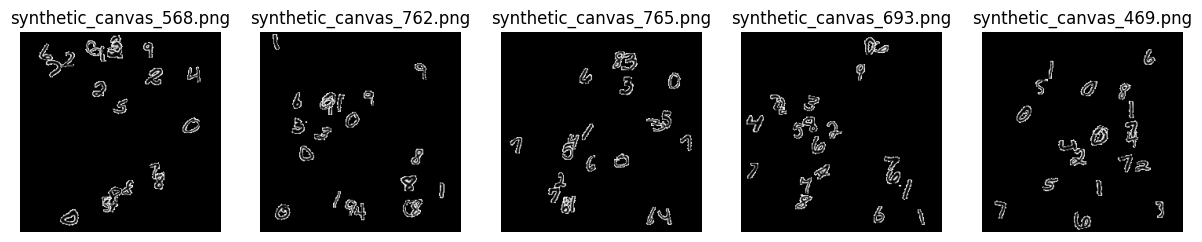

In [21]:
synthetic_files = os.listdir(synthetic_dir)
np.random.seed(42)  # for reproducibility
sample_files = np.random.choice(synthetic_files, size=5, replace=False)

# Plot the 5 random synthetic canvases
plt.figure(figsize=(15,3))
for i, fname in enumerate(sample_files):
    img_path = os.path.join(synthetic_dir, fname)
    img = img_to_array(load_img(img_path, color_mode='grayscale')).reshape(256,256)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(fname)
    plt.axis('off')

plt.show()